In [1]:
import math #libreria (radici,arrotondamenti)
import time #prendo l'orario per calcolare il time execution
from collections import defaultdict #non interrompe in caso di missing
from itertools import combinations #mi serve assolutamente, devo prendere le associazioni generiche e non ordinate,combinations ([a,b,c],2)=(a,b),(a,c),(b,c)
import matplotlib.pyplot as plt
import pandas as pd

import glob #per cercare tramite * qualsiasi file es.(non ricordo Elio petri "Indagine su un cittadino al di sopra di ogni sopetto" e lo cerco come "*al di sopra di ogni sospetto")
import zipfile #leggo (e scrivo nel caso) lo zip dei film

pd.set_option("display.max_colwidth", 60) #massimo 60 caratteri per stringa in una cella elaborata

In [2]:
import os
os.environ["KAGGLE_USERNAME"] = "gianmarcocostanzo1"
os.environ["KAGGLE_KEY"] = "Gian!030198"
#devo sostituire le mie crednziali con 'XXXXXXX'
DATASET_LINK = "harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows"
CSV_PATH = "imdb_top_1000.csv"


In [3]:
if os.path.exists(CSV_PATH):
    print(f"'{CSV_PATH}' gia' presente: salto il download da Kaggle.")
else:
    print("Download del dataset da Kaggle...")
    get_ipython().system('kaggle datasets download -d {DATASET_LINK}') #

    zip_candidates = glob.glob("*.zip") #nella cartella di riferimeto di jupiter faccio il check di esistenza dello zip
    if not zip_candidates:
        raise RuntimeError(
            "Nessun file .zip trovato: il download da Kaggle non e' andato a buon "
            "fine. Controlla che KAGGLE_USERNAME e KAGGLE_KEY siano credenziali "
            "valide (Kaggle -> Account -> Create New API Token)."
        ) #zip_candidates = ['imdb-dataset-of-top-1000-movies-and-tv-shows.zip'] ad oggi e quindi ora lo apro per estrarlo
    with zipfile.ZipFile(zip_candidates[0], "r") as z: #'r' per 'reAad e dopo lo nomino z
        z.extractall(".") #il "." per estrarlo nella cartella corrente
    print(f"Estratto: {zip_candidates[0]}") 

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(
        f"'{CSV_PATH}' non trovato dopo il download/estrazione: controlla il "
        "contenuto dello zip scaricato (potrebbe avere un nome diverso)."
    )
print(f"Dataset pronto: {CSV_PATH}")


'imdb_top_1000.csv' gia' presente: salto il download da Kaggle.
Dataset pronto: imdb_top_1000.csv


In [4]:
df = pd.read_csv(CSV_PATH)
n_colonne = df.shape[1]
star_cols = ["Star1", "Star2", "Star3", "Star4"]  #lista con i nomi delle colonne

#Unico errore noto nel CSV originale: Apollo 13 ha "PG" al posto dell'anno, (sfasamento di colonna a monte), il film è del 1995
df.loc[df["Series_Title"] == "Apollo 13", "Released_Year"] = "1995" #sostituzione del parametro sbagliato tramite ".loc" funzione indicizzatrice
df["Released_Year"] = pd.to_numeric(df["Released_Year"]).astype(int) #converto la colonna in (int)
df["Decade"] = df["Released_Year"] // 10 * 10 #divisione intera che scarta il decimale e rimoltiplico

buchi = df[star_cols].isna().sum().sum() #isna -> True(1)/False(0) per ogni cella primo sum per colonna, secondo sul totale
assert buchi == 0, "trovati valori mancanti in Star1-4"

#CREO I BASKET con gli attori, itertuples perché una tabella pandas non si può scorrere riga per riga altrimenti
baskets = [frozenset(row) for row in df[star_cols].itertuples(index=False, name=None)]#name=None tupla nuda senza etichette index=False niente numero di riga
N = len(baskets)

item_counts_preview = defaultdict(int)
for b in baskets:
    for item in b:
        item_counts_preview[item] += 1

print(f"Film / basket: {N}   |   Colonne: {n_colonne}")
print(f"Anni: {df['Released_Year'].min()}-{df['Released_Year'].max()}   |   "
      f"Voto IMDB: {df['IMDB_Rating'].min()}-{df['IMDB_Rating'].max()} "
      f"(media {df['IMDB_Rating'].mean():.2f})")
print(f"Attori distinti (item): {len(item_counts_preview)}   |   "
      f"Registi distinti: {df['Director'].nunique()}")
print(f"Valori mancanti nelle colonne attori: {buchi}")

nulls = df.isna().sum()
nulls = nulls[nulls > 0]
print(f"\nValori mancanti nelle altre colonne:\n{nulls.to_string()}")

print("\nDimensione dei basket:")
for s, n in pd.Series([len(b) for b in baskets]).value_counts().sort_index().items():
    print(f"  {s} attori: {n} film")

by_dec = df.groupby("Decade").agg(film=("Series_Title", "count"),
                                  voto_medio=("IMDB_Rating", "mean")).round(2)
print("\nFilm per decennio:")
by_dec

Film / basket: 1000   |   Colonne: 16
Anni: 1920-2020   |   Voto IMDB: 7.6-9.3 (media 7.95)
Attori distinti (item): 2709   |   Registi distinti: 548
Valori mancanti nelle colonne attori: 0

Valori mancanti nelle altre colonne:
Certificate    101
Meta_score     157
Gross          169

Dimensione dei basket:
  3 attori: 4 film
  4 attori: 996 film

Film per decennio:


,film,voto_medio
Decade,,
1920,11,8.13
1930,24,7.97
1940,35,8.03
1950,56,8.06
1960,73,7.97
1970,76,7.97
1980,89,7.95
1990,151,7.96
2000,237,7.90


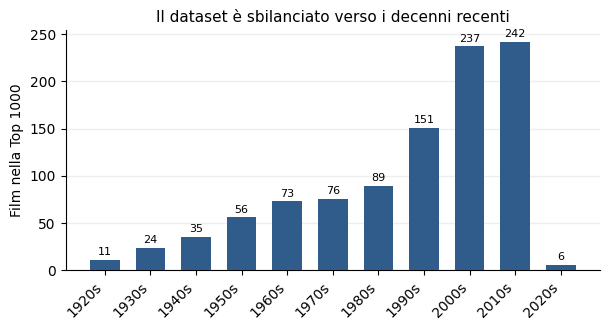

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 3.4))
bars = ax.bar([f"{d}s" for d in by_dec.index], by_dec["film"], color="#2F5C8A", width=0.65, zorder=3)

ax.set_ylabel("Film nella Top 1000")
ax.set_title("Il dataset è sbilanciato verso i decenni recenti", fontsize=11)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.grid(axis="y", color="#eeeeee", lw=1); ax.set_axisbelow(True) #Metto le righe comunque dietro le colonne
plt.xticks(rotation=45, ha="right") #ruoto i numerelli delle decadi

for bar, v in zip(bars, by_dec["film"]):
    ax.annotate(str(v), (bar.get_x() + bar.get_width()/2, bar.get_height()), #stringa col mio numerello che allineo al centro sopra il grafico
                 ha="center",va="bottom",fontsize=8,xytext=(0, 2), textcoords="offset points")

plt.tight_layout()
plt.savefig("figura_film_per_decennio.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [6]:
item_counts_preview = defaultdict(int) #default dict per non trovare errore in caso di missig
for b in baskets: #per ogni film (ogni riga o ogni insieme dei basket rappresenta un film)
    for item in b: #per ogni attore in quel film aggiorna il contatore
        item_counts_preview[item] += 1

print(f"Numero di attori distinti: {len(item_counts_preview)}")

top15 = sorted(item_counts_preview.items(), key=lambda x: -x[1])[:10]
top15_df = pd.DataFrame(top15, columns=["Attore", "Numero di film"])
top15_df.index = top15_df.index + 1
top15_df

Numero di attori distinti: 2709


,Attore,Numero di film
1,Robert De Niro,17
2,Tom Hanks,14
3,Al Pacino,13
4,Brad Pitt,12
5,Clint Eastwood,12
6,Christian Bale,11
7,Leonardo DiCaprio,11
8,Matt Damon,11
9,James Stewart,10
10,Michael Caine,9


In [7]:
#Soglia tarata sulla densità reale dei dati: s=3 tiene il 10% dei singleton (271/2709) e 25 coppie
#Con s=4 le coppie crollano a 5 con s=10 (l'1% del libro, Sez. 6.1.4) restano 9 attori e zero coppie
SUPPORT_THRESHOLD = 3

#A PRIORI: Classico giro in 2 step

# A-PRIORI, passo di conteggio: una sola passata sui basket per tutti i candidati di livello k
def count_candidates(baskets, candidates): 
    counts = defaultdict(int)
    cand_set = set(candidates) #set perchè elementa già hashati e immutabili, se frozenset non si può fare nemmeno add/remove
    for basket in baskets: #per ogni film
        for c in cand_set: #per ogni candidato
            if c.issubset(basket): #se c è un sottoinsieme di basket aumento il contatore di c
                counts[c] += 1
    return counts


def apriori_gen(prev_frequent_itemsets, k):    
    prev_list = list(prev_frequent_itemsets) #converto subito in lista perchè poi accedo a una certa posizione, ruota[i]
    candidates = set() #creo set vuoto
    n = len(prev_list)
    for i in range(n): #Per ogni frequente nel giro presente (singletond, soubleton, etc)
        for j in range(i + 1, n): #unisco 2 successivi
            union = prev_list[i] | prev_list[j]
            if len(union) == k: #se raggiugno k AB+AC=ABC
                if all(frozenset(s) in prev_frequent_itemsets for s in combinations(union, k - 1)): #controllo che tutti i minori siano presenti nel precedente frequent itemset
                    candidates.add(union) 
    return candidates


def apriori(baskets, support_threshold):
    stats = [] #lista vuota
    t0 = time.perf_counter() 
    item_counts = defaultdict(int) #setto con il solito defaultdict
    for basket in baskets:
        for item in basket:
            item_counts[frozenset([item])] += 1
    frequent = {k_: v for k_, v in item_counts.items() if v >= support_threshold} #riempo k_,v con l'oggetto di item_counts ({'gianmarco costanzo'}):3, ...
    all_frequent = dict(frequent)
    stats.append({"k": 1, "num_candidati": len(item_counts), "num_frequenti": len(frequent)})

    k = 2
    prev_frequent = frequent #Passo i singleton
    while prev_frequent:
        candidates = apriori_gen(prev_frequent, k) #inizialmente k=2 , 271 singleton, permuto e ho 271!/269!*2!= 36585
        if not candidates:
            break #else sottointeso
        counts = count_candidates(baskets, candidates) #conta i candidati su tutte le coppie o sulle triple
        frequent = {c: v for c, v in counts.items() if v >= support_threshold} #stesso ragionamento del frequent
        stats.append({"k": k, "num_candidati": len(candidates), "num_frequenti": len(frequent)})
        all_frequent.update(frequent)
        prev_frequent = frequent
        k += 1

    elapsed = time.perf_counter() - t0
    return all_frequent, stats, elapsed


In [8]:
apriori_freq, apriori_stats, apriori_time = apriori(baskets, SUPPORT_THRESHOLD)

print(f"Tempo A-Priori: {apriori_time:.3f} s")
print(f"Totale itemset frequenti trovati: {len(apriori_freq)}\n")
stats_df=pd.DataFrame(apriori_stats)
stats_df.index = stats_df.index + 1
stats_df

Tempo A-Priori: 4.790 s
Totale itemset frequenti trovati: 299



,k,num_candidati,num_frequenti
1,1,2709,271
2,2,36585,25
3,3,4,3


In [9]:
def show_top(freq, size, top_n=10): #Filtra gli itemset frequenti di una data dimensione e ne mostra i top_n per support.
    items = [(sorted(k), v) for k, v in freq.items() if len(k) == size] #Prima di tutto faccio una lista per ordinare correttamente e sorto subito i nomi in ordine alfabetico
    items.sort(key=lambda x: -x[1]) #guardo l'elemento [1] di sort, cioè il support e grazie al "-" ordino fecrescete
    return pd.DataFrame(items[:top_n], columns=[f"Itemset (size {size})", "Support"])

for size in [2, 3, 4]: #ciclo e stampo gli itemset
    print(f"--- Top itemset frequenti di dimensione {size} ---")
    display_df = show_top(apriori_freq, size)
    print(display_df if not display_df.empty else "(nessuno)")
    print()


--- Top itemset frequenti di dimensione 2 ---
                   Itemset (size 2)  Support
0  [Daniel Radcliffe, Rupert Grint]        6
1   [Daniel Radcliffe, Emma Watson]        5
2       [Emma Watson, Rupert Grint]        5
3       [Joe Pesci, Robert De Niro]        4
4            [Tim Allen, Tom Hanks]        4
5         [Al Pacino, Diane Keaton]        3
6   [Christian Bale, Michael Caine]        3
7       [Al Pacino, Robert De Niro]        3
8      [Elijah Wood, Orlando Bloom]        3
9       [Elijah Wood, Ian McKellen]        3

--- Top itemset frequenti di dimensione 3 ---
                                Itemset (size 3)  Support
0  [Daniel Radcliffe, Emma Watson, Rupert Grint]        5
1     [Elijah Wood, Ian McKellen, Orlando Bloom]        3
2    [Carrie Fisher, Harrison Ford, Mark Hamill]        3

--- Top itemset frequenti di dimensione 4 ---
(nessuno)



In [10]:
#Passo 1 (una scansione): conta i singoli item e, allo stesso tempo, fai l'hash di ogni coppia dentro il basket in una tabella hash con NUM_BUCKETS bucket, incrementando il contatore del bucket.
#Trasforma la tabella hash in una bitmap dei bucket "frequenti" (count >= soglia).
#Passo 2 (seconda scansione): una coppia {a, b} diventa candidata solo se entrambi gli item sono frequenti e la coppia hash-a in un bucket frequente. Solo queste coppie candidate vengono effettivamente contate.
#Il punto centrale del confronto: PCY tipicamente genera molte meno coppie candidate di A-Priori (che candida tutte le C(f,2) coppie di item frequenti), a costo di un po' di memoria per la tabella hash nel primo passo.

def pcy_frequent_pairs(baskets, support_threshold, num_buckets): #Trova le coppie frequenti con PCY. Restituisce (dict coppia->support, info).
    t0 = time.perf_counter()

    #Passo 1: conto singoli item + hash delle coppie nei bucket
    item_counts = defaultdict(int)
    bucket_counts = defaultdict(int)
    for basket in baskets:
        items = sorted(basket) #Ordino gli attori dentro i singoli basket
        for item in items:
            item_counts[item] += 1
        for a, b in combinations(items, 2):#genero tutte le combinazioni possibili dalla lista e le hasho
            h = hash((a, b)) % num_buckets
            bucket_counts[h] += 1

    frequent_items = {i for i, c in item_counts.items() if c >= support_threshold}
    frequent_buckets = {h for h, c in bucket_counts.items() if c >= support_threshold}

    #Passo 2: ricostruisco solo le coppie "candidate" e le conto
    candidate_pairs = set()
    for basket in baskets:
        items = sorted(x for x in basket if x in frequent_items) #guardo gli attori nei basket e tefo solo i freeuquenti sortati
        for a, b in combinations(items, 2):
            h = hash((a, b)) % num_buckets
            if h in frequent_buckets:
                candidate_pairs.add(frozenset([a, b]))

    pair_counts = count_candidates(baskets, candidate_pairs)
    frequent_pairs = {p: v for p, v in pair_counts.items() if v >= support_threshold}
    elapsed = time.perf_counter() - t0

    #per confronto: quante coppie candiderebbe A-Priori (tutte le coppie di item frequenti)
    naive_apriori_candidates = len(list(combinations(sorted(frequent_items), 2)))

    info = {
        "num_item_distinti": len(item_counts),
        "num_item_frequenti": len(frequent_items),
        "num_buckets": num_buckets,
        "num_bucket_frequenti": len(frequent_buckets),
        "num_coppie_candidate_PCY": len(candidate_pairs),
        "num_coppie_candidate_APriori": naive_apriori_candidates,
        "num_coppie_frequenti": len(frequent_pairs),
        "tempo_secondi": elapsed,
    }
    return frequent_pairs, info


In [11]:
NUM_BUCKETS = 70000  #da provare altre valorizzazioni
pcy_freq_pairs, pcy_info = pcy_frequent_pairs(baskets, SUPPORT_THRESHOLD, NUM_BUCKETS)
pd.Series(pcy_info)


num_item_distinti                2709.000000
num_item_frequenti                271.000000
num_buckets                     70000.000000
num_bucket_frequenti               37.000000
num_coppie_candidate_PCY           30.000000
num_coppie_candidate_APriori    36585.000000
num_coppie_frequenti               25.000000
tempo_secondi                       0.007659
dtype: float64

In [12]:
#Sanity check: PCY deve trovare esattamente le stesse coppie frequenti di A-Priori
apriori_pairs = {k: v for k, v in apriori_freq.items() if len(k) == 2}
assert apriori_pairs == pcy_freq_pairs, "PCY e A-Priori non concordano: controlla l'implementazione!"
print("OK: le coppie frequenti trovate da PCY coincidono con quelle di A-Priori.")


OK: le coppie frequenti trovate da PCY coincidono con quelle di A-Priori.


In [13]:
comparison = pd.DataFrame([
    {
        "Metrica": "Coppie candidate da contare",
        "A-Priori": pcy_info["num_coppie_candidate_APriori"],
        "PCY": pcy_info["num_coppie_candidate_PCY"],
    },
    {
        "Metrica": "Coppie frequenti trovate",
        "A-Priori": len(apriori_pairs),
        "PCY": pcy_info["num_coppie_frequenti"],
    },
    {
        "Metrica": "Tempo totale (s)",
        "A-Priori": round(apriori_time, 3),
        "PCY": round(pcy_info["tempo_secondi"], 3),
    },
])
comparison


,Metrica,A-Priori,PCY
0,Coppie candidate da contare,36585.00,30.000
1,Coppie frequenti trovate,25.00,25.000
2,Tempo totale (s),4.79,0.008


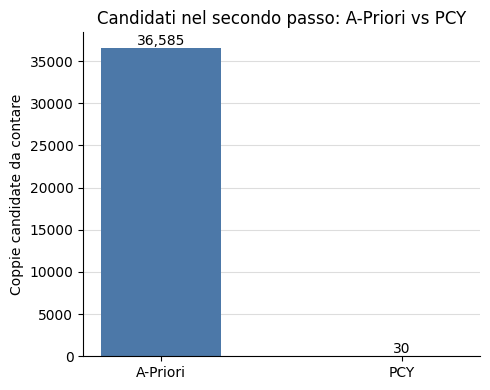

<Figure size 640x480 with 0 Axes>

In [14]:
#Grafico: coppie candidate da contare, A-Priori vs PCY ---
fig, ax = plt.subplots(figsize=(5, 4))

labels = ["A-Priori", "PCY"]
values = [pcy_info["num_coppie_candidate_APriori"], pcy_info["num_coppie_candidate_PCY"]]
color = "#4C78A8"  # singola tinta: stiamo confrontando una grandezza, non categorie diverse

bars = ax.bar(labels, values, color=color, width=0.5)
ax.set_ylabel("Coppie candidate da contare")
ax.set_title("Candidati nel secondo passo: A-Priori vs PCY")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#dddddd", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

for bar, v in zip(bars, values):
    ax.annotate(f"{v:,}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()
plt.savefig("figura_apriori_vs_pcy.png", dpi=300, bbox_inches="tight", facecolor="white")


In [15]:
def generate_rules(freq, N, min_confidence=0.5):
    # Da ogni itemset frequente I U {j}, genera la regola I -> j (confidence, interest).
    rules = []
    for itemset, support_ij in freq.items():
        if len(itemset) < 2:
            continue
        for j in itemset:
            antecedent = itemset - frozenset([j])
            support_i = freq.get(antecedent)
            if support_i is None:
                continue
            confidence = support_ij / support_i
            support_j = freq.get(frozenset([j]), 0)
            interest = confidence - (support_j / N)
            if confidence >= min_confidence:
                rules.append({
                    "Regola": f"{sorted(antecedent)} -> {j}",
                    "Support": support_ij,
                    "Confidence": round(confidence, 3),
                    "Interest": round(interest, 3),
                })
    rules.sort(key=lambda r: (-r["Confidence"], -r["Support"]))
    return pd.DataFrame(rules)

rules_df = generate_rules(apriori_freq, N, min_confidence=0.5)
print(f"Regole trovate (confidence >= 0.5): {len(rules_df)}")
rules_df.head(15)


Regole trovate (confidence >= 0.5): 39


,Regola,Support,Confidence,Interest
0,['Rupert Grint'] -> Daniel Radcliffe,6,1.0,0.994
1,['Daniel Radcliffe'] -> Rupert Grint,6,1.0,0.994
2,"['Emma Watson', 'Rupert Grint'] -> Daniel Radcliffe",5,1.0,0.994
3,"['Daniel Radcliffe', 'Emma Watson'] -> Rupert Grint",5,1.0,0.994
4,['Tim Allen'] -> Tom Hanks,4,1.0,0.986
5,['Elijah Wood'] -> Orlando Bloom,3,1.0,0.996
6,['Elijah Wood'] -> Ian McKellen,3,1.0,0.993
7,['Mark Hamill'] -> Harrison Ford,3,1.0,0.992
8,['Mark Hamill'] -> Carrie Fisher,3,1.0,0.996
9,['John Turturro'] -> Ethan Coen,3,1.0,0.994


In [16]:
def item_type(item):
    # "ACTOR::Tom Hanks" -> "ACTOR"
    return item.split("::", 1)[0]

def item_name(item):
    # "ACTOR::Tom Hanks" -> "Tom Hanks"
    return item.split("::", 1)[1]

def generate_rules_ext(freq, N):
    # Come generate_rules, ma aggiunge il lift: utile qui perche' i tre tipi
    # di item (attore/regista/fascia voto) hanno frequenze di base molto diverse.
    rules = []
    for itemset, support_ij in freq.items():
        if len(itemset) < 2:
            continue
        for j in itemset:
            antecedent = itemset - frozenset([j])
            support_i = freq.get(antecedent)
            if support_i is None:
                continue
            confidence = support_ij / support_i
            support_j = freq.get(frozenset([j]), 0)
            base_rate = support_j / N
            lift = confidence / base_rate if base_rate > 0 else float("nan")
            rules.append({
                "antecedent": antecedent,
                "consequent": j,
                "support": support_ij,
                "confidence": confidence,
                "lift": lift,
            })
    return rules


def rules_table(rules, antecedent_type, consequent_type, sort_by="confidence", top_n=15):
    # Filtra le regole a un solo item nell'antecedente e per tipo (es. DIRECTOR -> ACTOR).
    filtered = [
        r for r in rules
        if len(r["antecedent"]) == 1
        and item_type(next(iter(r["antecedent"]))) == antecedent_type
        and item_type(r["consequent"]) == consequent_type
    ]
    filtered.sort(key=lambda r: (-r[sort_by], -r["support"]))
    rows = [{
        antecedent_type.capitalize(): item_name(next(iter(r["antecedent"]))),
        consequent_type.capitalize(): item_name(r["consequent"]),
        "Support": r["support"],
        "Confidence": round(r["confidence"], 3),
        "Lift": round(r["lift"], 2),
    } for r in filtered[:top_n]]
    return pd.DataFrame(rows), len(filtered)


ext_rules = generate_rules_ext(ext_freq, N)
print(f"Totale regole (tutte le combinazioni di tipo): {len(ext_rules)}")


NameError: name 'ext_freq' is not defined

**Regista -> Star**: coppie regista-attore che tornano insieme più
spesso della norma. Ordinate per confidence (qui è la metrica giusta: ha
senso chiedersi "quando questo regista gira un film, con che probabilità
c'è questo attore?").


In [23]:
director_to_actor, n_found = rules_table(ext_rules, "DIRECTOR", "ACTOR", sort_by="confidence")
print(f"Regole trovate: {n_found}")
director_to_actor


Regole trovate: 47


,Director,Actor,Support,Confidence,Lift
0,Charles Chaplin,Charles Chaplin,6,1.000,166.67
1,Joel Coen,Ethan Coen,6,1.000,166.67
2,Peter Jackson,Ian McKellen,5,1.000,142.86
3,Anthony Russo,Joe Russo,4,1.000,250.00
4,Thomas Vinterberg,Thomas Bo Larsen,3,1.000,333.33
5,Stanley Kramer,Spencer Tracy,3,1.000,333.33
6,David Yates,Emma Watson,3,1.000,142.86
7,David Yates,Rupert Grint,3,1.000,166.67
8,David Yates,Daniel Radcliffe,3,1.000,166.67
9,Ron Clements,John Musker,3,1.000,333.33


**Punteggio -> Regista** e **Punteggio -> Star**: qui ordiniamo per
**lift**, non per confidence, per il motivo spiegato sopra. Un lift alto per
la fascia "Capolavoro" indica un regista/attore sovra-rappresentato tra i
film più votati — attenzione però che quella fascia ha solo ~53 film, quindi
questi risultati vanno letti come indizio, non come prova statistica (un
buon punto da discutere criticamente nella relazione).


In [24]:
rating_to_director, n_found_1 = rules_table(ext_rules, "RATING", "DIRECTOR", sort_by="lift")
print(f"Regole trovate: {n_found_1}")
rating_to_director


Regole trovate: 60


,Rating,Director,Support,Confidence,Lift
0,Capolavoro (>=8.5),Peter Jackson,3,0.057,11.32
1,Capolavoro (>=8.5),Christopher Nolan,4,0.075,9.43
2,Ottimo (8.0-8.4),Ingmar Bergman,7,0.017,2.44
3,Ottimo (8.0-8.4),Andrei Tarkovsky,5,0.012,2.44
4,Ottimo (8.0-8.4),Rajkumar Hirani,4,0.010,2.44
5,Ottimo (8.0-8.4),David Lean,4,0.010,2.44
6,Ottimo (8.0-8.4),Pete Docter,4,0.010,2.44
7,Ottimo (8.0-8.4),Emir Kusturica,3,0.007,2.44
8,Ottimo (8.0-8.4),William Wyler,3,0.007,2.44
9,Ottimo (8.0-8.4),Akira Kurosawa,9,0.022,2.20


In [25]:
rating_to_actor, n_found_2 = rules_table(ext_rules, "RATING", "ACTOR", sort_by="lift")
print(f"Regole trovate: {n_found_2}")
rating_to_actor


Regole trovate: 162


,Rating,Actor,Support,Confidence,Lift
0,Capolavoro (>=8.5),Elijah Wood,3,0.057,18.87
1,Capolavoro (>=8.5),Orlando Bloom,3,0.057,14.15
2,Capolavoro (>=8.5),Ian McKellen,3,0.057,8.09
3,Capolavoro (>=8.5),Tom Hanks,3,0.057,4.04
4,Capolavoro (>=8.5),Robert De Niro,3,0.057,3.33
5,Ottimo (8.0-8.4),Aamir Khan,8,0.020,2.44
6,Ottimo (8.0-8.4),Akshay Kumar,5,0.012,2.44
7,Ottimo (8.0-8.4),Amitabh Bachchan,4,0.010,2.44
8,Ottimo (8.0-8.4),Anthony Quinn,3,0.007,2.44
9,Ottimo (8.0-8.4),Orson Welles,3,0.007,2.44


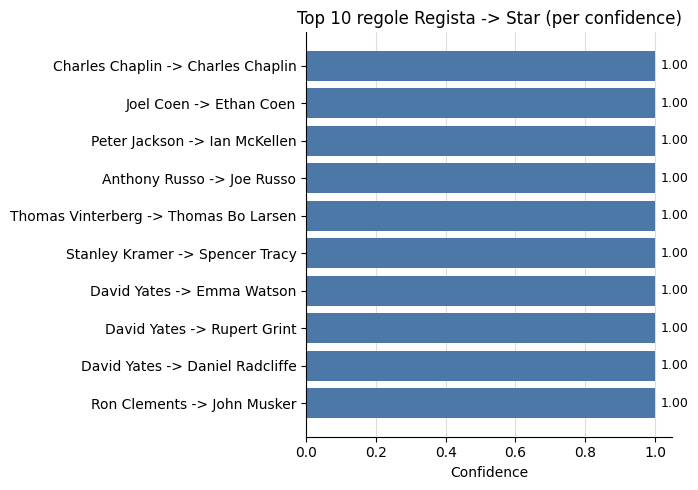

In [26]:
# --- Grafico: top 10 coppie regista-attore per confidence ---
top_da = director_to_actor.head(10).iloc[::-1]
labels = top_da["Director"] + " -> " + top_da["Actor"]

fig, ax = plt.subplots(figsize=(7, 5))
color = "#4C78A8"
bars = ax.barh(labels, top_da["Confidence"], color=color)
ax.set_xlabel("Confidence")
ax.set_title("Top 10 regole Regista -> Star (per confidence)")
ax.set_xlim(0, 1.05)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", color="#dddddd", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

for bar, v in zip(bars, top_da["Confidence"]):
    ax.annotate(f"{v:.2f}", (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                ha="left", va="center", fontsize=9, xytext=(4, 0), textcoords="offset points")

plt.tight_layout()
plt.show()


**Sì, c'è un forte bias verso i film recenti**: quasi due terzi del
dataset viene da tre soli decenni (1990-2010). Non è una sorpresa in sé — su
IMDB sono stati votati molti più film recenti che classici — ma significa
che qualunque pattern di *co-occorrenza* (attori, o come vedremo tra poco)
ha molte più occasioni di emergere nei decenni più popolati semplicemente
per una questione di campione, non necessariamente perché nella realtà
"si ripetono di più".


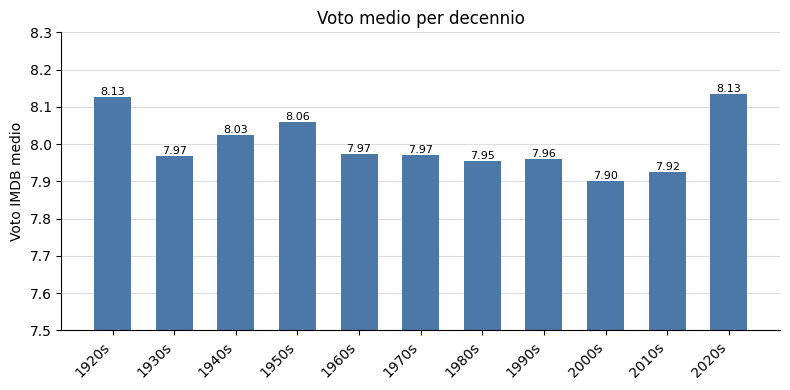

Correlazione (numero di film, voto medio) per decennio: -0.77


In [29]:
# --- Grafico: voto medio per decennio ---
fig, ax = plt.subplots(figsize=(8, 4))
color = "#4C78A8"

bars = ax.bar(decade_labels, by_decade["voto_medio"], color=color, width=0.6)
ax.set_ylabel("Voto IMDB medio")
ax.set_title("Voto medio per decennio")
ax.set_ylim(7.5, 8.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#dddddd", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
plt.xticks(rotation=45, ha="right")

for bar, v in zip(bars, by_decade["voto_medio"]):
    ax.annotate(f"{v:.2f}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

corr = by_decade["num_film"].corr(by_decade["voto_medio"])
print(f"Correlazione (numero di film, voto medio) per decennio: {corr:.2f}")


**Correlazione negativa** (circa -0.77): i decenni più rappresentati
(2000s, 2010s) hanno in media un voto leggermente **più basso** dei decenni
con pochi film (1920s, 1950s). È coerente con un effetto di
*sopravvivenza*: per essere ricordati e votati ancora oggi, i pochi film
degli anni '20-'50 presenti in una classifica "Top 1000 di sempre" devono
essere autentici classici, mentre nei decenni recenti il bacino di film
idonei è enorme e basta un voto un po' più basso per entrare comunque in
classifica. Non è quindi "i film moderni sono peggiori": è che il filtro
"Top 1000" è molto più severo, in proporzione, sui film vecchi.


In [30]:
def frequent_pairs_for_baskets(baskets, threshold):
    # Come A-Priori limitato a k=1,2: riusa count_candidates gia' definita.
    item_counts = defaultdict(int)
    for b in baskets:
        for item in b:
            item_counts[item] += 1
    frequent_items = {frozenset([i]) for i, c in item_counts.items() if c >= threshold}

    cands = set()
    fl = list(frequent_items)
    for i in range(len(fl)):
        for j in range(i + 1, len(fl)):
            cands.add(fl[i] | fl[j])

    counts = count_candidates(baskets, cands)
    return {c: v for c, v in counts.items() if v >= threshold}


decade_rows = []
for decade, sub in df.groupby("Decade"):
    dec_baskets = [frozenset(r) for r in sub[star_cols].itertuples(index=False, name=None)]
    freq_pairs_fixed = frequent_pairs_for_baskets(dec_baskets, SUPPORT_THRESHOLD)
    decade_rows.append({
        "Decade": decade,
        "Num_film": len(dec_baskets),
        "Voto_medio": sub["IMDB_Rating"].mean(),
        "Coppie_frequenti_soglia_fissa": len(freq_pairs_fixed),
    })

decade_analysis = pd.DataFrame(decade_rows)
corr_bias = decade_analysis["Num_film"].corr(decade_analysis["Coppie_frequenti_soglia_fissa"])
print(f"Correlazione (numero di film, numero di coppie frequenti) per decennio: {corr_bias:.2f}")
decade_analysis


Correlazione (numero di film, numero di coppie frequenti) per decennio: 0.81


,Decade,Num_film,Voto_medio,Coppie_frequenti_soglia_fissa
0,1920,11,8.127273,0
1,1930,24,7.966667,0
2,1940,35,8.025714,1
3,1950,56,8.058929,1
4,1960,73,7.973973,1
5,1970,76,7.969737,1
6,1980,89,7.953933,0
7,1990,151,7.960927,0
8,2000,237,7.899578,7
9,2010,242,7.924380,4


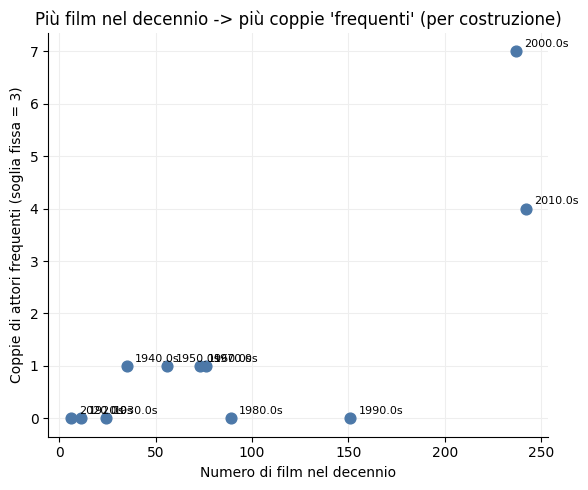

In [31]:
# --- Grafico: scatter numero di film vs coppie frequenti trovate, per decennio ---
fig, ax = plt.subplots(figsize=(6, 5))
color = "#4C78A8"

ax.scatter(decade_analysis["Num_film"], decade_analysis["Coppie_frequenti_soglia_fissa"],
           color=color, s=60, zorder=3)
for _, row in decade_analysis.iterrows():
    ax.annotate(f"{row['Decade']}s", (row["Num_film"], row["Coppie_frequenti_soglia_fissa"]),
                textcoords="offset points", xytext=(6, 3), fontsize=8)

ax.set_xlabel("Numero di film nel decennio")
ax.set_ylabel("Coppie di attori frequenti (soglia fissa = 3)")
ax.set_title("Più film nel decennio -> più coppie 'frequenti' (per costruzione)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(color="#eeeeee", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


Il grafico è piuttosto netto: i decenni con più film (2000s, 2010s)
concentrano quasi tutte le coppie frequenti trovate nella Sez. 4, mentre
decenni come gli anni '30-'60 — pur avendo avuto sicuramente attori
ricorrenti (pensiamo ai contratti "a studio" di Hollywood, o ai registi che
lavoravano sempre con gli stessi attori) — non raggiungono quasi mai la
soglia assoluta di 3 semplicemente perché ci sono pochi film candidati.
**Confermato: gran parte dell'effetto "le saghe recenti dominano" nella
Sez. 4 è un artefatto della soglia di supporto assoluta unita a un dataset
sbilanciato**, non necessariamente un fenomeno cinematografico reale.


In [32]:
REL_SUPPORT = SUPPORT_THRESHOLD / N  # stessa frazione della soglia globale (0.3%)

relative_rows = []
hidden_pairs = []  # coppie trovate SOLO con soglia relativa, non con soglia fissa
for decade, sub in df.groupby("Decade"):
    dec_baskets = [frozenset(r) for r in sub[star_cols].itertuples(index=False, name=None)]
    n_dec = len(dec_baskets)
    rel_threshold = max(2, math.ceil(n_dec * REL_SUPPORT))

    freq_fixed = frequent_pairs_for_baskets(dec_baskets, SUPPORT_THRESHOLD)
    freq_relative = frequent_pairs_for_baskets(dec_baskets, rel_threshold)

    relative_rows.append({
        "Decade": decade, "Num_film": n_dec, "Soglia_relativa": rel_threshold,
        "Coppie_soglia_fissa": len(freq_fixed), "Coppie_soglia_relativa": len(freq_relative),
    })

    for pair, supp in freq_relative.items():
        if pair not in freq_fixed:
            hidden_pairs.append({"Decade": decade, "Coppia": " & ".join(sorted(pair)), "Support": supp})

pd.DataFrame(relative_rows)


,Decade,Num_film,Soglia_relativa,Coppie_soglia_fissa,Coppie_soglia_relativa
0,1920,11,2,0,0
1,1930,24,2,0,4
2,1940,35,2,1,3
3,1950,56,2,1,4
4,1960,73,2,1,6
5,1970,76,2,1,3
6,1980,89,2,0,10
7,1990,151,2,0,7
8,2000,237,2,7,25
9,2010,242,2,4,25


In [33]:
hidden_df = pd.DataFrame(hidden_pairs).sort_values(["Decade", "Support"], ascending=[True, False])
print(f"Coppie 'nascoste' dalla soglia fissa, recuperate con soglia relativa: {len(hidden_df)}")
hidden_df[hidden_df["Decade"] < 1990].head(20)


Coppie 'nascoste' dalla soglia fissa, recuperate con soglia relativa: 72


,Decade,Coppia,Support
0,1930,Chico Marx & Harpo Marx,2
1,1930,Groucho Marx & Harpo Marx,2
2,1930,Chico Marx & Groucho Marx,2
3,1930,Boris Karloff & Colin Clive,2
4,1940,Claude Rains & Ingrid Bergman,2
5,1940,Joseph Cotten & Orson Welles,2
6,1950,Minoru Chiaki & Toshirô Mifune,2
7,1950,Karl Malden & Marlon Brando,2
8,1950,John Wayne & Ward Bond,2
9,1960,Clint Eastwood & Lee Van Cleef,2


Con una soglia relativa emergono coppie storicamente molto note che
la soglia fissa a 3 tagliava fuori solo perché i loro decenni hanno pochi
film in classifica: i fratelli Marx negli anni '30, Humphrey Bogart e
Lauren Bacall negli anni '40, i film di Kurosawa con Toshirô Mifune negli
anni '50-'60, le coppie dei western "spaghetti" di Clint Eastwood negli
anni '60, il cast originale di **Star Wars** e **Ritorno al Futuro** negli
anni '80. Sono esattamente il tipo di pattern "storico" che ci si
aspetterebbe, ma restavano invisibili con una soglia assoluta pensata per
il dataset nel suo complesso.

**Nota per la relazione**: il decennio 2020 ha solo 6 film (il dataset è
stato raccolto quando il decennio era appena iniziato), quindi va escluso
da qualunque confronto — non è un decennio "povero di collaborazioni", è
semplicemente incompleto. Allo stesso modo, la coppia Mark Hamill/Harrison
Ford (Star Wars) risultava già frequente con soglia fissa nella Sez. 4:
buon promemoria che il bias è una tendenza aggregata, non una regola senza
eccezioni — alcune saghe sono abbastanza dominanti da emergere comunque.


In [35]:
def movies_for_pair(sub_df, a, b):
    # I film (in sub_df) in cui compaiono entrambi gli attori a e b tra Star1-4.
    mask = sub_df[star_cols].apply(lambda r: a in r.values and b in r.values, axis=1)
    return sub_df[mask]


hidden_movie_rows = []
for _, row in hidden_df.iterrows():
    a, b = row["Coppia"].split(" & ")
    dec_sub = df[df["Decade"] == row["Decade"]]
    for _, m in movies_for_pair(dec_sub, a, b).iterrows():
        hidden_movie_rows.append({
            "Decade": row["Decade"], "Coppia": row["Coppia"], "Film": m["Series_Title"],
            "Voto": m["IMDB_Rating"], "Percentile": round(m["Percentile"], 1),
        })

hidden_movies = pd.DataFrame(hidden_movie_rows).drop_duplicates(subset=["Film", "Coppia"])
pre90_movies = hidden_movies[hidden_movies["Decade"] < 1990].drop_duplicates(subset=["Film"])

print(f"Film distinti dietro le coppie 'nascoste' pre-1990: {len(pre90_movies)}")
print(pre90_movies["Percentile"].describe().round(1))

quota_top5 = (pre90_movies["Percentile"] >= 95).mean()
print(f"\nQuota di questi film nel top 5% (percentile >= 95): {quota_top5:.0%}")


Film distinti dietro le coppie 'nascoste' pre-1990: 33
count    33.0
mean     68.1
std      23.8
min      20.2
25%      48.4
50%      74.2
75%      89.5
max      99.9
Name: Percentile, dtype: float64

Quota di questi film nel top 5% (percentile >= 95): 18%


In [36]:
pre90_movies.sort_values("Percentile", ascending=False).head(15)[["Film", "Decade", "Voto", "Percentile"]]


,Film,Decade,Voto,Percentile
28,The Godfather,1970,9.2,99.9
29,The Godfather: Part II,1970,9.0,99.7
18,"Il buono, il brutto, il cattivo",1960,8.8,99.0
32,Star Wars: Episode V - The Empire Strikes Back,1980,8.7,98.5
44,Back to the Future,1980,8.5,95.8
8,Casablanca,1940,8.5,95.8
33,Star Wars: Episode VI - Return of the Jedi,1980,8.3,89.5
10,Citizen Kane,1940,8.3,89.5
19,Per qualche dollaro in più,1960,8.3,89.5
22,The Great Escape,1960,8.2,83.9


Confermato in larga parte: la **mediana è intorno al 74° percentile**
(cioè "nel miglior 26%", non nel miglior 5%) — film come *Taxi Driver*,
*Quarto Potere* (Citizen Kane, anch'esso all'89°), *Il terzo uomo*. Ma non
è una regola assoluta: **quasi 1 film su 5** di questo gruppo è comunque
un vero top-5% — *Il Padrino*, *L'Impero Colpisce Ancora*, *Casablanca*,
*Ritorno al Futuro*. Confrontiamo ora con le coppie "ufficiali" trovate
nella Sez. 4 (soglia fissa, in maggioranza saghe recenti), per capire se
essere "frequente" è di per sé collegato a votazione più alta.


In [37]:
official_movie_rows = []
for pair in apriori_pairs:
    a, b = tuple(pair)
    for _, m in movies_for_pair(df, a, b).iterrows():
        official_movie_rows.append({
            "Coppia": f"{a} & {b}", "Film": m["Series_Title"], "Percentile": m["Percentile"],
        })

official_movies = pd.DataFrame(official_movie_rows).drop_duplicates(subset=["Film", "Coppia"]).drop_duplicates(subset=["Film"])

print(f"Film distinti dietro le coppie frequenti 'ufficiali' (Sez. 4): {len(official_movies)}")
print(official_movies["Percentile"].describe().round(1))
print(f"\nQuota nel top 5%: {(official_movies['Percentile'] >= 95).mean():.0%}")


Film distinti dietro le coppie frequenti 'ufficiali' (Sez. 4): 51
count    51.0
mean     63.4
std      31.7
min       6.2
25%      35.6
50%      74.2
75%      93.2
max      99.9
Name: Percentile, dtype: float64

Quota nel top 5%: 22%


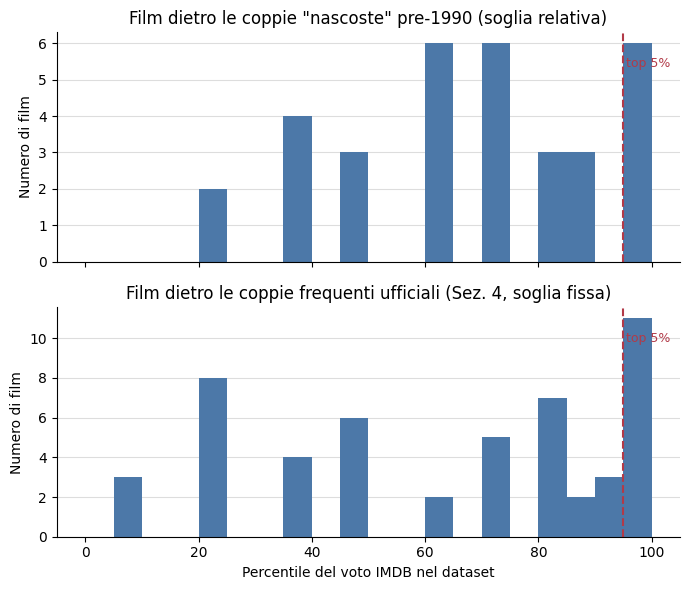

In [38]:
# --- Grafico: distribuzione dei percentili, coppie nascoste pre-1990 vs coppie ufficiali ---
fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
color = "#4C78A8"
bins = range(0, 101, 5)

axes[0].hist(pre90_movies["Percentile"], bins=bins, color=color)
axes[0].set_title("Film dietro le coppie \"nascoste\" pre-1990 (soglia relativa)")
axes[0].axvline(95, color="#B23A48", linestyle="--", linewidth=1.5)
axes[0].text(95.5, axes[0].get_ylim()[1] * 0.85, "top 5%", color="#B23A48", fontsize=9)

axes[1].hist(official_movies["Percentile"], bins=bins, color=color)
axes[1].set_title("Film dietro le coppie frequenti ufficiali (Sez. 4, soglia fissa)")
axes[1].axvline(95, color="#B23A48", linestyle="--", linewidth=1.5)
axes[1].text(95.5, axes[1].get_ylim()[1] * 0.85, "top 5%", color="#B23A48", fontsize=9)
axes[1].set_xlabel("Percentile del voto IMDB nel dataset")

for ax in axes:
    ax.set_ylabel("Numero di film")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="#dddddd", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


In [40]:
BANDS = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]  # soglie "top X%" da verificare


def topx_counts_and_confidence(df, bands):
    # Per ogni decennio e ogni soglia top-X%, restituisce sia il conteggio
    # assoluto di film che rientrano in quella soglia, sia la confidence
    # (conteggio / film totali del decennio) -- le due facce della stessa
    # domanda, cfr. la Sez. 6.1.4 su support vs confidence.
    count_rows, confidence_rows = [], []
    for decade, sub in df.groupby("Decade"):
        n = len(sub)
        count_row = {"Decade": decade, "n_film": n}
        confidence_row = {"Decade": decade, "n_film": n}
        for x in bands:
            cutoff = 100 - x
            cnt = int((sub["Percentile"] >= cutoff).sum())
            count_row[f"top{x}%"] = cnt
            confidence_row[f"top{x}%"] = round(cnt / n, 3)
        count_rows.append(count_row)
        confidence_rows.append(confidence_row)
    return pd.DataFrame(count_rows), pd.DataFrame(confidence_rows)


counts_table, confidence_table = topx_counts_and_confidence(df, BANDS)

print("--- Numeri assoluti: quanti film di ogni decennio cadono in ciascuna soglia ---")
counts_table


--- Numeri assoluti: quanti film di ogni decennio cadono in ciascuna soglia ---


,Decade,n_film,top5%,top10%,top15%,top20%,top25%,top30%,top35%,top40%,top45%,top50%
0,1920,11,0,0,2,4,4,9,9,10,10,10
1,1930,24,2,2,3,3,3,7,7,11,11,11
2,1940,35,2,3,6,8,8,13,13,22,22,22
3,1950,56,2,6,10,18,18,27,27,40,40,40
4,1960,73,4,6,10,14,14,26,26,38,38,38
5,1970,76,4,7,10,15,15,25,25,36,36,36
6,1980,89,4,7,14,20,20,31,31,41,41,41
7,1990,151,17,18,24,31,31,49,49,68,68,68
8,2000,237,10,16,22,36,36,58,58,88,88,88
9,2010,242,6,17,25,44,44,74,74,106,106,106


In [41]:
print("--- Confidence: P(film nel top X% | decennio) ---")
confidence_table


--- Confidence: P(film nel top X% | decennio) ---


,Decade,n_film,top5%,top10%,top15%,top20%,top25%,top30%,top35%,top40%,top45%,top50%
0,1920,11,0.000,0.000,0.182,0.364,0.364,0.818,0.818,0.909,0.909,0.909
1,1930,24,0.083,0.083,0.125,0.125,0.125,0.292,0.292,0.458,0.458,0.458
2,1940,35,0.057,0.086,0.171,0.229,0.229,0.371,0.371,0.629,0.629,0.629
3,1950,56,0.036,0.107,0.179,0.321,0.321,0.482,0.482,0.714,0.714,0.714
4,1960,73,0.055,0.082,0.137,0.192,0.192,0.356,0.356,0.521,0.521,0.521
5,1970,76,0.053,0.092,0.132,0.197,0.197,0.329,0.329,0.474,0.474,0.474
6,1980,89,0.045,0.079,0.157,0.225,0.225,0.348,0.348,0.461,0.461,0.461
7,1990,151,0.113,0.119,0.159,0.205,0.205,0.325,0.325,0.450,0.450,0.450
8,2000,237,0.042,0.068,0.093,0.152,0.152,0.245,0.245,0.371,0.371,0.371
9,2010,242,0.025,0.070,0.103,0.182,0.182,0.306,0.306,0.438,0.438,0.438


Le due tabelle rispondono a domande diverse e **nessuna delle due è
sbagliata**:

- In **numeri assoluti**, il 2010 (242 film) mette sul piatto 106 film sopra
  la mediana — più del triplo di tutti gli anni '20-'50 messi insieme (73).
  Se la domanda è "quale decennio ha contribuito con più film oggi
  considerati tra i migliori di sempre", vince nettamente il 2010, per puro
  volume.
- In **confidence** (proporzione), un film del 1950 ha il 71% di probabilità
  di stare sopra la mediana, contro il 44% di uno del 2010. Se la domanda è
  "dato un film di quel decennio, quanto è probabile che sia tra i
  migliori", vincono nettamente i decenni vecchi.

È la stessa tensione fra **support** (conteggio assoluto, cresce con il
numero di basket disponibili) e **confidence** (proporzione, la corregge)
che guida tutta la Sez. 6.1.4 del libro sulla scelta della soglia. Qui si
vede in modo particolarmente pulito perché "decennio" è una variabile che
cambia moltissimo di dimensione (da 6 a 242 film), mentre in un dataset più
omogeneo l'effetto sarebbe meno visibile.


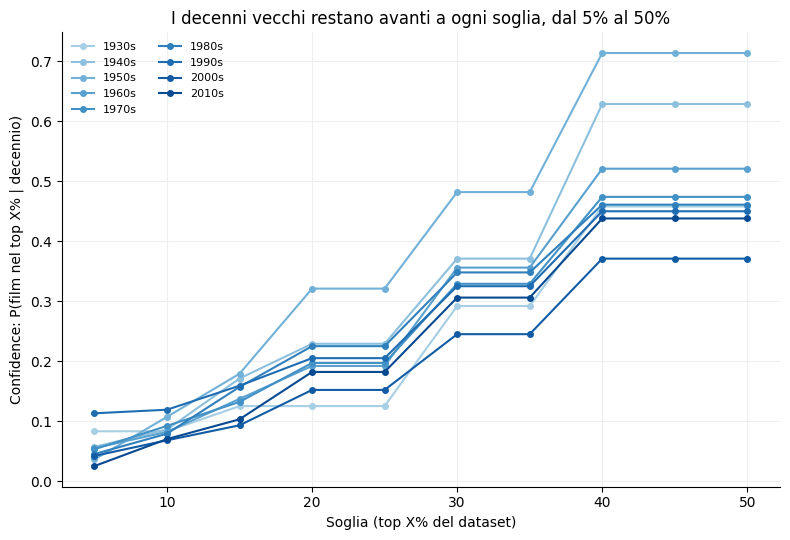

In [42]:
# --- Grafico: confidence per decennio a soglie percentili crescenti ---
# Il decennio e' una variabile ORDINATA (cronologica), quindi usiamo una
# scala di colori sequenziale (chiaro=vecchio, scuro=recente) invece di
# colori categorici arbitrari. Escludiamo 1920 e 2020 dal grafico (n troppo
# piccolo, gia' discusso sopra) ma restano nelle tabelle con la loro nota.
reliable = confidence_table[~confidence_table["Decade"].isin([1920, 2020])].sort_values("Decade")
decades_sorted = reliable["Decade"].tolist()
cmap = plt.cm.Blues
colors = [cmap(0.35 + 0.55 * i / (len(decades_sorted) - 1)) for i in range(len(decades_sorted))]

fig, ax = plt.subplots(figsize=(8, 5.5))
for color, (_, row) in zip(colors, reliable.iterrows()):
    y = [row[f"top{x}%"] for x in BANDS]
    ax.plot(BANDS, y, marker="o", markersize=4, color=color, label=f"{int(row['Decade'])}s")

ax.set_xlabel("Soglia (top X% del dataset)")
ax.set_ylabel("Confidence: P(film nel top X% | decennio)")
ax.set_title("I decenni vecchi restano avanti a ogni soglia, dal 5% al 50%")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(color="#eeeeee", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.legend(loc="upper left", fontsize=8, ncol=2, frameon=False)

plt.tight_layout()
plt.show()


Il grafico mostra che il vantaggio dei decenni vecchi (in confidence)
non è un artefatto della sola soglia 5%: si mantiene su tutto l'intervallo
fino al 50%. Coerente con la lettura "a sopravvivenza" della Sez. 10: un
film pre-1990 in questa classifica ha già superato decenni di selezione del
pubblico, un film del 2010 no — non ha ancora avuto il tempo di essere
"scremato" allo stesso modo.
